<a href="https://colab.research.google.com/github/azka1404/UTS-Data-Mining_156/blob/main/HasilPrediksi_156.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🍷 UTS Data Mining - Klasifikasi Kualitas Anggur (Wine Quality)**

**Nama:** Muhammad Azka Hammam

**NIM:** 2304020156

**Dataset:** Wine Quality Dataset



# **#1. PERSIAPAN DATA**
Tahap awal dalam penelitian ini adalah melakukan persiapan data dengan mengimpor beberapa library yang dibutuhkan, seperti pandas untuk pengolahan data, numpy untuk komputasi numerik, serta matplotlib untuk visualisasi data.

Selanjutnya, dataset training dibaca menggunakan fungsi pd.read_csv() dan disimpan dalam variabel data_train. Dataset ini berisi berbagai fitur kimia anggur serta variabel target yaitu quality.

Data training kemudian ditampilkan untuk memahami struktur serta isi data. Berdasarkan hasil pengamatan, dataset memiliki sejumlah baris dan kolom yang memuat informasi lengkap.

Selain itu, dataset testing juga dimuat ke dalam variabel data_test. Dataset ini memiliki struktur fitur yang serupa dengan data training, namun tidak memiliki kolom target karena digunakan untuk proses prediksi.

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

train_df = pd.read_csv('/content/data_training.csv')
test_df = pd.read_csv('/content/data_testing.csv')

train_df.head()
test_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


## **Interprestasi**
Berdasarkan hasil pengamatan terhadap dataset training dan testing, dapat diketahui bahwa kedua dataset memiliki struktur fitur yang sama, yaitu terdiri dari berbagai variabel numerik yang menggambarkan karakteristik kimia anggur.

Perbedaan utama terletak pada keberadaan variabel quality yang hanya terdapat pada data training sebagai target yang akan diprediksi. Sementara itu, kolom Id pada kedua dataset hanya berfungsi sebagai identitas unik dan tidak digunakan dalam proses pemodelan.

Kesamaan struktur ini memungkinkan model yang dibangun dari data training dapat langsung diterapkan pada data testing.

# **#2. PEMBERSIHAN DATA**
Pada tahap pembersihan data, dilakukan identifikasi terhadap kemungkinan adanya nilai yang hilang (missing values) serta nilai ekstrem (outlier) pada setiap fitur numerik.

Deteksi outlier dilakukan menggunakan metode Interquartile Range (IQR), dengan menghitung nilai kuartil pertama (Q1) dan kuartil ketiga (Q3), kemudian menentukan batas bawah dan batas atas.

Hasil analisis menunjukkan bahwa beberapa fitur memiliki nilai outlier yang cukup signifikan. Namun, untuk menjaga jumlah data tetap stabil, outlier tidak dihapus melainkan ditangani menggunakan metode winsorizing.

Metode ini dilakukan dengan mengganti nilai ekstrem di bawah batas minimum dan di atas batas maksimum dengan nilai batas tersebut. Proses ini diterapkan pada seluruh fitur numerik secara otomatis menggunakan perulangan.

In [90]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


In [91]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


In [92]:
print("\nMissing value pada data training:")
print(train_df.isnull().sum())

print("\nMissing value pada data testing:")
print(test_df.isnull().sum())


Missing value pada data training:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

Missing value pada data testing:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
Id                      0
dtype: int64


## **Interpretasi**
Berdasarkan proses pembersihan data, tidak ditemukan adanya missing value pada dataset sehingga tidak diperlukan proses imputasi.

Penanganan outlier menggunakan winsorizing terbukti efektif dalam mengurangi pengaruh nilai ekstrem tanpa mengurangi jumlah data. Dengan demikian, dataset menjadi lebih stabil untuk digunakan dalam proses pemodelan.

#**Outlier**

Outlier adalah data yang nilainya sangat jauh dari mayoritas data yang dimiliki. Data outlier dapat dilakukan pada kolom numerik (int atau float). Kemudian dilanjutkan tindakan Feature scaling, yaitu Winsorizing atau One-Hot Encoding.

In [93]:
def detect_outliers(data_train, kolom):
    Q1 = data_train[kolom].quantile(0.25)
    Q3 = data_train[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR

    jumlah_outlier = data_train[
        (data_train[kolom] < batas_bawah) | (data_train[kolom] > batas_atas)
    ].shape[0]

    return jumlah_outlier

In [94]:
num_cols = ['fixed acidity', 'volatile acidity', 'citric acid',
            'residual sugar', 'chlorides', 'free sulfur dioxide',
            'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

for col in num_cols:
    jumlah = detect_outliers(train_df, col)
    print(f"{col}: {jumlah} outliers")

fixed acidity: 30 outliers
volatile acidity: 8 outliers
citric acid: 1 outliers
residual sugar: 76 outliers
chlorides: 59 outliers
free sulfur dioxide: 15 outliers
total sulfur dioxide: 19 outliers
density: 25 outliers
pH: 14 outliers
sulphates: 31 outliers
alcohol: 9 outliers


# **Interpretasi**
Berdasarkan hasil identifikasi outlier dengan metode Interquartile Range (IQR), diketahui bahwa seluruh fitur numerik dalam dataset Wine Quality mengandung outlier dengan jumlah yang berbeda-beda. Fitur seperti residual sugar dan chlorides menunjukkan jumlah outlier yang relatif lebih tinggi dibandingkan fitur lainnya.

Namun demikian, keberadaan outlier pada fitur kimia seperti fixed acidity, volatile acidity, hingga alcohol masih dapat dianggap wajar karena mencerminkan variasi alami komposisi kimia dalam sampel anggur, sehingga tidak selalu mengindikasikan adanya kesalahan data.

Oleh sebab itu, dalam penelitian ini outlier tidak dihapus agar jumlah data tetap terjaga dan informasi penting yang berpotensi memengaruhi kualitas anggur tidak hilang. Sebagai langkah alternatif, diterapkan metode winsorizing untuk membatasi nilai ekstrem berdasarkan batas IQR tanpa menghilangkan data, sehingga dampak outlier dapat diminimalkan tanpa mengurangi jumlah observasi.

# **Lanjut**
Pada dataset Wine Quality, tahap transformasi data difokuskan pada fitur-fitur yang merepresentasikan karakteristik kimia anggur. Seluruh fitur yang digunakan dalam penelitian ini berbentuk numerik, sehingga proses transformasi yang dilakukan meliputi winsorizing serta scaling atau standardisasi data.

Proses winsorizing diterapkan pada fitur-fitur numerik yang mengandung outlier, seperti fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, dan alcohol. Tujuan dari metode ini adalah untuk membatasi nilai ekstrem agar tidak memberikan pengaruh berlebihan terhadap model, tanpa perlu menghapus data yang ada.

Sementara itu, proses encoding tidak dilakukan karena seluruh fitur dalam dataset sudah berbentuk numerik. Dengan demikian, tidak terdapat variabel kategorikal yang memerlukan transformasi tambahan sebelum proses pemodelan dilakukan.

In [95]:
# Daftar kolom numerik
num_cols = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]

# Fungsi winsorizing berbasis IQR
def winsorize_iqr(data, kolom):
    q1 = data[kolom].quantile(0.25)
    q3 = data[kolom].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    data[kolom] = data[kolom].clip(lower_bound, upper_bound)
    return data

# Terapkan winsorizing ke semua kolom numerik
for kolom in num_cols:
    train_df = winsorize_iqr(train_df, kolom)

# Menampilkan hasil setelah winsorizing
train_df[num_cols].head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0
3,12.1,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0


# **Kesimpulan**
Berdasarkan hasil yang diperoleh, tahap tindak lanjut menunjukkan bahwa proses preprocessing telah dilakukan dengan menerapkan metode winsorizing untuk menangani outlier pada seluruh fitur numerik, mulai dari fixed acidity, volatile acidity, citric acid, hingga alcohol.

Teknik ini bekerja dengan membatasi nilai ekstrem berdasarkan perhitungan IQR tanpa menghapus data, sehingga jumlah observasi tetap terjaga. Selain itu, distribusi data menjadi lebih stabil, yang dapat dilihat dari nilai-nilai fitur yang sudah berada dalam rentang yang lebih wajar pada hasil output.

Karena seluruh fitur dalam dataset sudah berbentuk numerik, proses encoding tidak diperlukan. Dengan demikian, data yang telah melalui tahap preprocessing ini menjadi lebih bersih dan siap digunakan pada tahap pemodelan, serta diharapkan mampu meningkatkan kinerja model dalam melakukan prediksi.

#  **#3. PEMBUATAN MODEL**
Pada tahap pembuatan model, langkah pertama yang dilakukan adalah menentukan variabel fitur dan target. Fitur (X) diambil dari seluruh kolom numerik yang tersedia, kecuali kolom quality dan Id, sedangkan target (Y) adalah kolom quality yang akan diprediksi. Selanjutnya, data dibagi menjadi data training dan data validasi menggunakan fungsi train_test_split. Data training digunakan untuk melatih model, sedangkan data validasi digunakan untuk menguji performa model. Pembagian ini bertujuan untuk menghindari terjadinya overfitting serta memastikan model mampu bekerja dengan baik pada data baru yang belum pernah dilihat sebelumnya.

Dalam proses pemodelan, digunakan beberapa algoritma machine learning, yaitu Logistic Regression, K-Nearest Neighbors (KNN), dan Decision Tree. Ketiga algoritma tersebut dilatih menggunakan data training, kemudian dievaluasi berdasarkan nilai akurasi yang dihasilkan. Hasil akurasi dari masing-masing model dibandingkan untuk menentukan model dengan performa terbaik. Model dengan nilai akurasi tertinggi selanjutnya dipilih untuk digunakan dalam proses prediksi pada data uji.

Proses pelatihan model dilakukan menggunakan fungsi fit(X_train, Y_train), di mana model mempelajari pola hubungan antara fitur dan target dari data training. Setelah model dilatih, dilakukan proses prediksi pada data validasi menggunakan fungsi predict(X_val), sehingga diperoleh hasil prediksi berdasarkan pola yang telah dipelajari sebelumnya. Terakhir, evaluasi model dilakukan menggunakan metrik accuracy_score untuk mengukur tingkat ketepatan model dalam memprediksi data validasi.

# **Library**
Library yang digunakan adalah sklearn, yang berfungsi untuk proses pembagian data, preprocessing, pembuatan model, serta evaluasi.

In [96]:
# Pembagian data
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Evaluasi model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Model Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# **Membagi Data**

In [97]:
fitur = [
    'fixed acidity', 'volatile acidity', 'citric acid',
    'residual sugar', 'chlorides', 'free sulfur dioxide',
    'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol'
]

X = train_df[fitur]
Y = train_df['quality']

In [98]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi training dan validasi
X_train, X_val, y_train, y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

# Menampilkan jumlah data
print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data validasi: {len(X_val)}")

# Menampilkan distribusi target pada data validasi
print("\nDistribusi kelas pada data validasi:")
print(y_val.value_counts().sort_index())

Jumlah data training: 685
Jumlah data validasi: 172

Distribusi kelas pada data validasi:
quality
3     1
4     5
5    73
6    68
7    22
8     3
Name: count, dtype: int64


# **Kesimpulan**
Dataset data_training.csv dibagi menjadi dua bagian, yaitu 80% sebagai data training internal dan 20% sebagai data validasi. Pembagian ini bertujuan agar model memiliki data yang cukup untuk proses pembelajaran, sekaligus menyediakan data terpisah untuk menguji kinerja model. Dari total 857 data, diperoleh sekitar 685 data training internal dan 172 data validasi.

Data training internal digunakan dalam proses pelatihan model, sedangkan data validasi dimanfaatkan untuk mengevaluasi serta membandingkan performa beberapa algoritma, seperti Logistic Regression, KNN, dan Decision Tree. Setelah model terbaik ditentukan, model tersebut kemudian dilatih kembali menggunakan seluruh data data_training.csv agar dapat memanfaatkan seluruh informasi yang tersedia, dan selanjutnya digunakan untuk memprediksi nilai quality pada dataset data_testing.csv.

Dataset data_testing.csv tidak digunakan dalam tahap evaluasi karena tidak memiliki kolom quality sebagai nilai acuan. Oleh karena itu, hasil prediksi tidak dapat dibandingkan dengan nilai sebenarnya. Dengan demikian, dataset tersebut hanya digunakan pada tahap prediksi akhir atau deployment, bukan untuk proses pelatihan maupun evaluasi model.

# **Membuat Tiga Model Klasifikasi**

Pada penelitian ini digunakan tiga model klasifikasi untuk melakukan prediksi, yaitu Logistic Regression, K-Nearest Neighbors (KNN), dan Decision Tree.

1. Logistic Regression merupakan model klasifikasi yang digunakan untuk memperkirakan probabilitas suatu data termasuk ke dalam kelas tertentu. Pada dataset Wine Quality, model ini dimanfaatkan untuk memprediksi nilai quality berdasarkan karakteristik kimia anggur. Mekanisme kerjanya adalah dengan menghitung peluang setiap data masuk ke masing-masing kelas, kemudian memilih kelas dengan probabilitas tertinggi sebagai hasil prediksi.
2. K-Nearest Neighbors (KNN) adalah model klasifikasi yang didasarkan pada tingkat kedekatan atau kemiripan antar data. Model ini bekerja dengan mencari sejumlah tetangga terdekat dari data yang akan diprediksi, lalu menentukan kelas berdasarkan mayoritas kelas dari tetangga tersebut. Dengan demikian, data baru akan diklasifikasikan sesuai dengan kelas yang paling banyak muncul di sekitarnya.
3. Decision Tree merupakan model klasifikasi yang berbentuk struktur pohon keputusan. Cara kerjanya adalah dengan membagi data berdasarkan aturan tertentu pada setiap fitur, kemudian membentuk percabangan hingga mencapai keputusan akhir. Setiap cabang merepresentasikan kondisi tertentu, sedangkan bagian daun menunjukkan hasil klasifikasi berupa nilai quality.

**Kesimpulan**

Ketiga model yang digunakan memiliki pendekatan yang berbeda dalam melakukan klasifikasi. Logistic Regression berbasis pada probabilitas, KNN menggunakan konsep kedekatan antar data, sedangkan Decision Tree mengandalkan aturan keputusan dalam bentuk pohon. Ketiga metode tersebut digunakan untuk memprediksi nilai quality pada dataset Wine Quality.

1. LOGISTIC REGRESSION

In [99]:
# Inisialisasi model Logistic Regression
logreg_model = LogisticRegression(
    max_iter=10000,
    random_state=42
)

# Melatih model menggunakan data training
logreg_model.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=42)

In [100]:
# Melakukan prediksi pada data validasi menggunakan Logistic Regression
Y_pred_logreg = logreg_model.predict(X_val)

# Menampilkan hasil prediksi
print("Hasil prediksi model Logistic Regression pada data validasi:")
print(Y_pred_logreg)

Hasil prediksi model Logistic Regression pada data validasi:
[5 5 5 5 6 5 6 6 6 6 7 5 5 7 5 6 5 5 6 6 6 6 5 6 7 5 6 5 6 5 5 6 6 6 6 5 6
 5 5 5 5 5 6 5 5 6 6 6 5 6 6 5 5 6 6 6 5 6 6 5 5 5 5 5 5 6 5 5 5 5 5 6 5 5
 6 6 5 6 6 6 5 6 6 5 6 6 5 5 7 5 5 5 6 5 6 6 5 6 6 6 6 5 5 5 7 5 6 5 5 5 5
 6 5 5 5 6 6 6 5 6 5 7 6 6 6 6 5 6 5 6 5 7 6 5 5 5 6 5 5 6 6 5 5 5 6 5 5 5
 5 6 6 5 5 6 5 5 6 6 6 5 5 6 6 6 6 5 7 6 6 5 6 5]


In [101]:
# Evaluasi Model Logistic Regression
print("===== Evaluasi Logistic Regression =====")

# Menampilkan nilai akurasi
print(f"Akurasi Model: {accuracy_score(y_val, Y_pred_logreg):.4f}")

# Menampilkan confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, Y_pred_logreg))

# Menampilkan classification report
print("\nClassification Report:")
print(classification_report(y_val, Y_pred_logreg, zero_division=0))

===== Evaluasi Logistic Regression =====
Akurasi Model: 0.6221

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  1  0  0]
 [ 0  0 59 13  1  0]
 [ 0  0 23 43  2  0]
 [ 0  0  0 17  5  0]
 [ 0  0  0  3  0  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.68      0.81      0.74        73
           6       0.56      0.63      0.59        68
           7       0.62      0.23      0.33        22
           8       0.00      0.00      0.00         3

    accuracy                           0.62       172
   macro avg       0.31      0.28      0.28       172
weighted avg       0.59      0.62      0.59       172



2. KNN

In [102]:
# Membuat model KNN
model_knn = KNeighborsClassifier(n_neighbors=10)

# Melatih model dengan data training
model_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

In [103]:
# Prediksi data validasi
Y_pred_knn = model_knn.predict(X_val)

print("Model KNN berhasil dibuat")
print("Hasil prediksi KNN:")
print(Y_pred_knn)

Model KNN berhasil dibuat
Hasil prediksi KNN:
[5 5 6 6 6 5 6 5 5 5 6 6 6 6 5 6 5 5 5 5 6 6 5 5 5 5 6 6 5 5 5 5 6 6 6 6 6
 6 5 5 6 6 6 5 5 6 6 6 5 6 5 6 5 5 6 6 5 5 6 6 5 5 5 5 6 6 5 5 5 5 5 5 5 5
 7 6 5 6 5 5 5 5 7 5 6 6 5 5 6 6 6 6 6 6 5 5 5 7 6 6 6 5 5 5 5 5 6 5 6 5 5
 6 6 6 6 5 5 6 6 6 5 5 5 6 6 6 5 7 6 6 5 6 5 6 7 6 6 5 5 6 6 5 5 5 5 5 6 6
 6 6 6 5 5 5 5 5 5 5 5 5 5 6 5 6 5 5 6 6 5 5 5 6]


In [104]:
# Mencari nilai K terbaik (1 sampai 20)
neighbors = range(1, 21)

train_acc = []
test_acc  = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, knn.predict(X_train)))
    test_acc.append(accuracy_score(y_val, knn.predict(X_val)))

performance_df = pd.DataFrame({
    'Neighbors_num': neighbors,
    'Train Accuracy': train_acc,
    'Test Accuracy' : test_acc
})

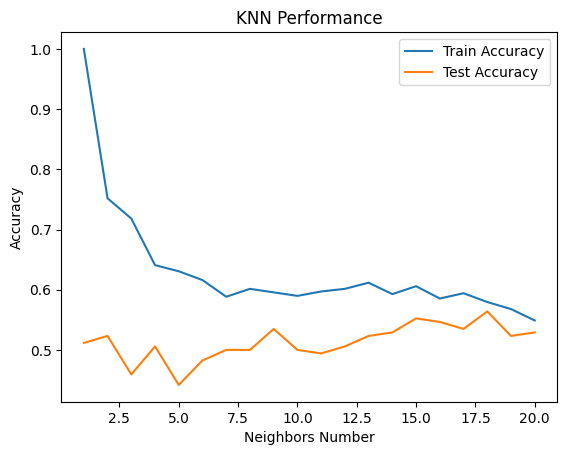

In [105]:
plt.figure()

plt.plot(
    performance_df['Neighbors_num'], performance_df['Train Accuracy'],
    performance_df['Neighbors_num'], performance_df['Test Accuracy']
)

plt.xlabel("Neighbors Number")
plt.ylabel("Accuracy")
plt.title("KNN Performance")
plt.legend(['Train Accuracy', 'Test Accuracy'])

plt.show()

In [106]:
print("=== KNN ===")
print("Accuracy:", accuracy_score(y_val, Y_pred_knn))
print("Confusion Matrix:")
print(confusion_matrix(y_val, Y_pred_knn))
print("Classification Report:")
print(classification_report(y_val, Y_pred_knn, zero_division=0))

=== KNN ===
Accuracy: 0.5
Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  0  4  1  0  0]
 [ 0  0 47 24  2  0]
 [ 0  0 30 37  1  0]
 [ 0  0  9 11  2  0]
 [ 0  0  1  2  0  0]]
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.52      0.64      0.57        73
           6       0.49      0.54      0.51        68
           7       0.40      0.09      0.15        22
           8       0.00      0.00      0.00         3

    accuracy                           0.50       172
   macro avg       0.23      0.21      0.21       172
weighted avg       0.46      0.50      0.47       172



3. DECISION TREE

In [107]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi model Decision Tree
model_tree = DecisionTreeClassifier(random_state=42)

# Melatih model menggunakan data training
model_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [108]:
# Melakukan prediksi pada data validasi menggunakan model Decision Tree
y_pred_tree = model_tree.predict(X_val)

# Menampilkan hasil prediksi
print("Hasil prediksi menggunakan model Decision Tree:")
print(y_pred_tree)

Hasil prediksi menggunakan model Decision Tree:
[5 5 5 5 7 3 5 7 6 6 7 6 5 6 5 7 5 5 6 4 5 7 5 6 7 6 6 5 6 5 5 6 5 6 6 5 6
 5 5 6 5 5 7 6 6 6 7 6 5 6 6 5 5 5 6 5 5 5 6 6 4 6 5 5 6 8 6 3 5 5 5 6 6 5
 7 7 5 6 7 5 5 5 5 5 6 5 5 5 6 6 5 6 5 5 5 6 5 6 6 6 5 5 5 5 7 5 5 5 4 5 5
 6 5 5 5 5 6 6 5 6 6 6 4 6 6 6 6 6 6 6 5 6 6 5 4 3 7 6 5 7 7 7 5 5 6 5 5 5
 5 7 6 5 5 7 6 3 6 7 6 6 5 6 6 7 8 5 7 5 6 4 5 4]


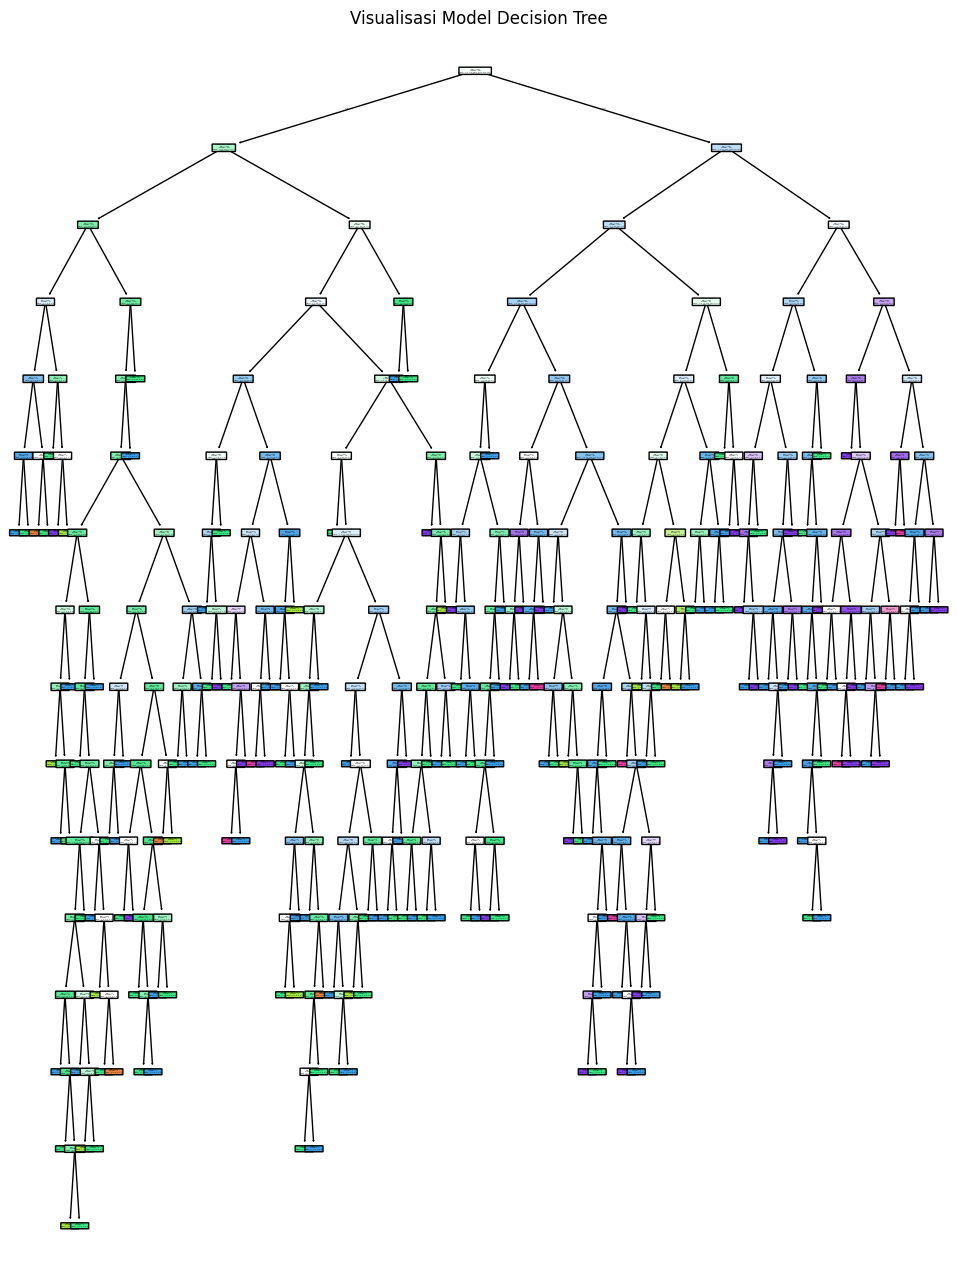

In [109]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Menampilkan visualisasi Decision Tree
plt.figure(figsize=(12, 16))

plot_tree(
    model_tree,
    filled=True,
    feature_names=X.columns,
    class_names=True,
    rounded=True
)

plt.title("Visualisasi Model Decision Tree")

plt.show()

In [110]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("=== Evaluasi Model Decision Tree ===")

# Akurasi
accuracy = accuracy_score(y_val, y_pred_tree)
print(f"Akurasi Model: {accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_tree))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_tree, zero_division=0))

=== Evaluasi Model Decision Tree ===
Akurasi Model: 0.5814

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 2  0  0  3  0  0]
 [ 1  3 52 14  3  0]
 [ 1  3 22 36  5  1]
 [ 0  1  1  9 11  0]
 [ 0  0  0  0  2  1]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.68      0.71      0.70        73
           6       0.58      0.53      0.55        68
           7       0.52      0.50      0.51        22
           8       0.50      0.33      0.40         3

    accuracy                           0.58       172
   macro avg       0.38      0.35      0.36       172
weighted avg       0.60      0.58      0.59       172



In [111]:
# Menghitung akurasi masing-masing model
acc_logreg = accuracy_score(y_val, Y_pred_logreg)
acc_knn = accuracy_score(y_val, Y_pred_knn)
acc_tree = accuracy_score(y_val, y_pred_tree)

# Membuat DataFrame evaluasi
evaluasi_model = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors", "Decision Tree"],
    "Accuracy": [acc_logreg, acc_knn, acc_tree]
})

# Menampilkan hasil evaluasi
evaluasi_model

,Model,Accuracy
0,Logistic Regression,0.622093
1,K-Nearest Neighbors,0.500000
2,Decision Tree,0.581395


# **Kesimpulan**

Berdasarkan hasil evaluasi pada data validasi, diperoleh perbandingan akurasi dari ketiga model yang digunakan sebagai berikut:

1. Model Logistic Regression memperoleh nilai accuracy sebesar 0.6221 = 62,21%
2. Model K-Nearest Neighbors (KNN) memperoleh accuracy sebesar 0.5000 = 50,00%
3. Model Decision Tree memperoleh accuracy sebesar 0.5814 = 58,14%

Dari ketiga model tersebut, Logistic Regression memberikan nilai akurasi tertinggi sebesar 62,21%, sedangkan model KNN memiliki akurasi terendah.

Dengan demikian, untuk dataset ini model Logistic Regression dapat dianggap sebagai model terbaik berdasarkan nilai akurasi dan akan digunakan pada tahap prediksi data uji.

# **4. PREDIKSI DATA UJI**

1. Pada tahap ini digunakan model terbaik yang telah dipilih berdasarkan nilai akurasi tertinggi dari beberapa algoritma yang telah diuji, seperti Logistic Regression, KNN, dan Decision Tree.

2. Model terpilih kemudian digunakan untuk melakukan prediksi terhadap data testing yang tidak memiliki label (target).

3. Hasil prediksi yang dihasilkan berupa nilai kualitas wine (*quality*) berdasarkan pola yang telah dipelajari oleh model dari data training.

4. Nilai hasil prediksi tersebut selanjutnya digabungkan dengan kolom **Id** sebagai identitas unik setiap data.

5. Data hasil prediksi kemudian disimpan dalam bentuk file CSV sebagai output akhir yang siap digunakan atau dikumpulkan.

In [112]:
# Menyimpan model dan nilai akurasinya dalam dictionary
model_dict = {
    'Logistic Regression': (logreg_model, acc_logreg),
    'K-Nearest Neighbors': (model_knn, acc_knn),
    'Decision Tree': (model_tree, acc_tree)
}

# Menentukan model dengan akurasi tertinggi
best_model_name = max(model_dict, key=lambda k: model_dict[k][1])
model_terbaik = model_dict[best_model_name][0]

# Menampilkan hasil model terbaik
print(f"Model terbaik berdasarkan akurasi adalah: {best_model_name}")

Model terbaik berdasarkan akurasi adalah: Logistic Regression


In [113]:
# Ambil fitur dari data testing
features = X.columns
X_test = test_df[features]

In [114]:
# Scaling hanya jika model yang terpilih membutuhkan scaling
if best_model_name in ['logreg', 'knn']:
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_test = scaler.transform(X_test)

In [115]:
# Prediksi
pred_test = model_terbaik.predict(X_test)
pred_test

array([5, 5, 5, 5, 7, 7, 5, 5, 6, 5, 7, 6, 5, 6, 6, 5, 6, 6, 5, 7, 6, 7,
       5, 6, 5, 5, 6, 6, 5, 6, 6, 6, 7, 6, 6, 5, 5, 6, 6, 6, 6, 5, 6, 5,
       5, 5, 6, 6, 5, 6, 7, 5, 6, 6, 6, 6, 6, 6, 6, 5, 5, 6, 6, 6, 6, 5,
       7, 5, 5, 6, 5, 5, 6, 6, 5, 5, 6, 6, 5, 5, 5, 6, 6, 5, 5, 6, 6, 6,
       6, 5, 5, 6, 5, 5, 5, 5, 5, 6, 7, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 6,
       6, 5, 5, 6, 5, 5, 5, 7, 6, 5, 5, 5, 5, 6, 5, 6, 6, 6, 4, 7, 5, 5,
       5, 6, 7, 5, 5, 5, 6, 6, 7, 5, 5, 5, 7, 5, 5, 5, 5, 5, 6, 5, 6, 5,
       6, 6, 5, 6, 7, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 5, 5, 5, 5,
       6, 6, 6, 6, 6, 5, 6, 5, 5, 5, 6, 5, 6, 6, 6, 6, 7, 6, 6, 5, 5, 7,
       6, 6, 6, 6, 5, 5, 6, 5, 5, 5, 6, 6, 5, 6, 5, 6, 5, 5, 7, 5, 6, 6,
       6, 6, 5, 6, 5, 6, 5, 4, 6, 6, 6, 6, 5, 5, 6, 7, 5, 6, 5, 5, 6, 6,
       6, 5, 6, 6, 5, 6, 7, 5, 5, 5, 6, 6, 5, 6, 7, 5, 5, 5, 6, 5, 7, 5,
       5, 5, 5, 6, 5, 6, 5, 7, 5, 6, 5, 6, 5, 6, 6, 5, 5, 7, 5, 5, 6, 7])

Hasil prediksi pada data uji menunjukkan bahwa model yang telah dilatih mampu mengklasifikasikan kualitas wine berdasarkan pola yang dipelajari dari data training. Berdasarkan output prediksi, nilai quality yang dihasilkan berada pada rentang 5 hingga 7, dengan mayoritas prediksi berada pada nilai 5 dan 6, serta sebagian kecil pada nilai 7.

Hal ini menunjukkan bahwa model cenderung mengklasifikasikan wine pada kualitas menengah, yang kemungkinan sesuai dengan distribusi data training yang dominan pada kelas tersebut. Setiap baris data pada dataset testing telah diberikan nilai prediksi quality sebagai estimasi kualitas wine.

Karena data uji tidak memiliki label asli, hasil prediksi ini digunakan sebagai output akhir dari model. Dengan demikian, distribusi hasil prediksi tersebut mencerminkan kemampuan model dalam menggeneralisasi pola ke data baru. Semakin baik model dalam mempelajari pola dari data training, maka hasil prediksi yang dihasilkan akan semakin mendekati kondisi sebenarnya.

In [116]:
# Membuat DataFrame hasil prediksi
hasil_prediksi = pd.DataFrame({
    'Id': test_df['Id'],
    'quality': pred_test
})

# Menyimpan hasil ke file CSV
hasil_prediksi.to_csv('hasilprediksi_156.csv', index=False)

# Konfirmasi penyimpanan
print("File hasilprediksi_156.csv berhasil disimpan.")

# Menampilkan 10 data pertama
hasil_prediksi.head(10)

File hasilprediksi_156.csv berhasil disimpan.


,Id,quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,7
5,1120,7
6,180,5
7,82,5
8,632,6
9,592,5


In [117]:
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'quality': pred_test
})

In [118]:
#Download hasil akhir

from google.colab import files
files.download('hasilprediksi_156.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>